# Experiment: TS Missing Folder Distribution

目标：分析 `Data/csvs/First_12000.csv` 中未出现在 `Data/TS/Borane_all.csv` 的 TS，并按照 `6_Draw_Figures.ipynb` / `Figure 5A` 使用的相同类别划分方式，统计其 `B_type`、`Cl_type` 和 `LB_type` 分布。

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib.util
import sys

import pandas as pd
from IPython.display import Image, display

analysis_path = Path('output/jupyter-notebook/ts_missing_folder_distribution_analysis.py').resolve()
spec = importlib.util.spec_from_file_location('ts_missing_analysis', analysis_path)
module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = module
spec.loader.exec_module(module)

result = module.run_analysis()
summary_df = result['summary_df']
combo_df = result['combo_df']
missing_df = result['missing']
figure_path = result['figure_path']
print(f"Missing TS: {result['missing_count']} / {result['total_count']}")
summary_df.head()

Missing TS: 3020 / 12000


,dimension,category,missing_count,missing_fraction,first_12000_count,missing_rate_within_first_12000
0,B_type,BR3,0,0.000000,0,<NA>
1,B_type,R2BH,1698,0.562252,4108,0.41334
2,B_type,RBH2,976,0.323179,6756,0.144464
3,B_type,BH3,346,0.114570,1136,0.304577
4,Cl_type,CCl4,19,0.006291,230,0.082609


## Matching Rule

将 `First_12000` 与 `Borane_all` 按以下 5 列匹配：

- `B_Index`
- `N_Index`
- `Cl_Index`
- `B_N_Cl_conf`
- `Cl_r_conf`

凡是只在 `First_12000` 中出现、未在 `Borane_all` 中匹配到的行，都视为“失败 / 缺失 TS”。

In [2]:
for dimension in ['B_type', 'Cl_type', 'LB_type']:
    display(summary_df.loc[summary_df['dimension'] == dimension].reset_index(drop=True))

,dimension,category,missing_count,missing_fraction,first_12000_count,missing_rate_within_first_12000
0,B_type,BR3,0,0.000000,0,<NA>
1,B_type,R2BH,1698,0.562252,4108,0.41334
2,B_type,RBH2,976,0.323179,6756,0.144464
3,B_type,BH3,346,0.114570,1136,0.304577


,dimension,category,missing_count,missing_fraction,first_12000_count,missing_rate_within_first_12000
0,Cl_type,CCl4,19,0.006291,230,0.082609
1,Cl_type,CCl3,391,0.129470,2168,0.180351
2,Cl_type,CCl2,494,0.163576,2572,0.192068
3,Cl_type,CCl,2116,0.700662,7030,0.300996


,dimension,category,missing_count,missing_fraction,first_12000_count,missing_rate_within_first_12000
0,LB_type,Amine/Aryl N,1362,0.450993,7104,0.191723
1,LB_type,Phosphine,1081,0.357947,2879,0.375478
2,LB_type,NHC,577,0.191060,2017,0.286068


## Pie Chart

下图沿用 `Figure 5A` 的三组类别定义，展示缺失 TS 的分布。

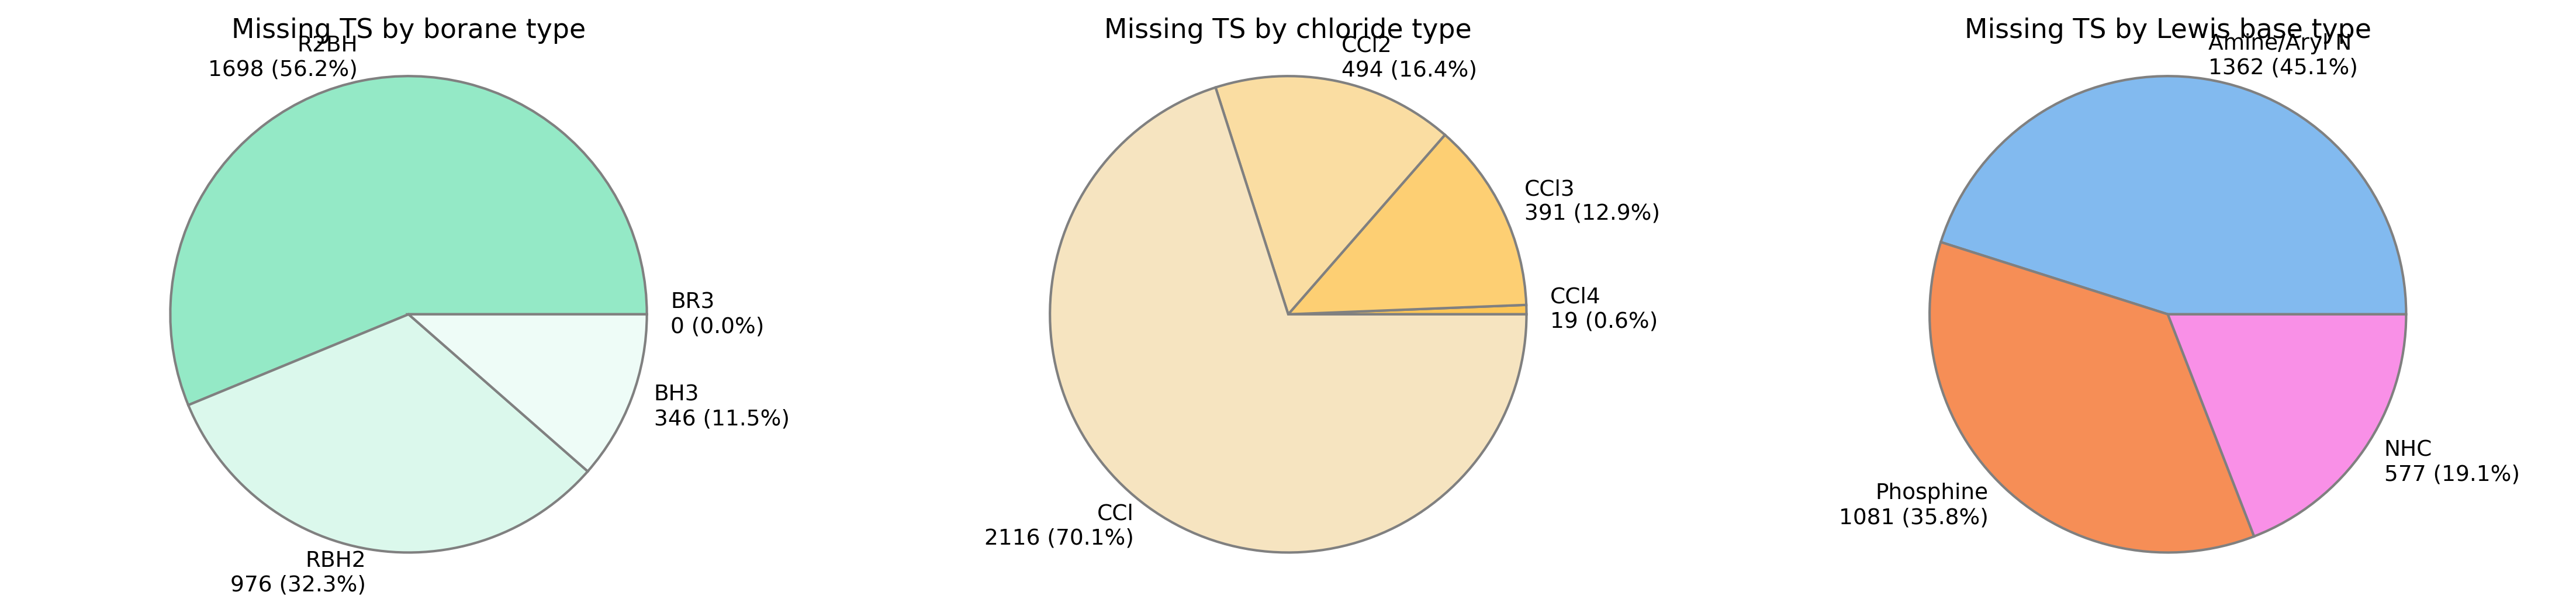

In [3]:
display(Image(filename=str(figure_path)))

## Top Combined Classes

为了看缺失是否集中在某些具体组合上，下面列出缺失数量最多的 `B_type / Cl_type / LB_type` 组合。

In [4]:
combo_df

,B_type,Cl_type,LB_type,missing_count,missing_fraction
0,R2BH,CCl,Phosphine,591,0.195695
1,R2BH,CCl,Amine/Aryl N,398,0.131788
2,RBH2,CCl,Amine/Aryl N,338,0.111921
3,R2BH,CCl,NHC,244,0.080795
4,RBH2,CCl,Phosphine,205,0.067881
5,RBH2,CCl,NHC,186,0.061589
6,BH3,CCl,Amine/Aryl N,120,0.039735
7,R2BH,CCl2,Amine/Aryl N,113,0.037417
8,BH3,CCl2,Amine/Aryl N,111,0.036755
9,R2BH,CCl2,Phosphine,105,0.034768
